<a href="https://colab.research.google.com/github/alifnw/3-Alif-Livyandra/blob/livyandra/Weekly_Report_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Background

Kematian ibu akibat komplikasi kehamilan merupakan indikator
kritis dalam sistem kesehatan global. Identifikasi dini terhadap
pasien berisiko tinggi menjadi kunci dalam menekan angka tersebut,
namun proses penilaian risiko yang masih bersifat manual rentan
terhadap keterlambatan dan subjektivitas. Proyek ini mengembangkan
model klasifikasi berbasis machine learning menggunakan data klinis
ibu hamil untuk mengotomatisasi deteksi risiko komplikasi, sehingga
tenaga medis dapat mengambil keputusan klinis yang lebih cepat
dan berbasis data.

#Import Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import missingno as msno

In [33]:
filepath = 'https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/main/Dataset%20-%20Updated.csv'
df = pd.read_csv(filepath)
df

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,High
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,High
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,High
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,High


####**About Dataset**

Dataset ini berisi data kesehatan ibu hamil yang dapat dimanfaatkan oleh rumah sakit, klinik, maupun penyedia layanan kesehatan untuk meningkatkan kualitas layanan maternal secara lebih terstruktur dan berbasis data. Parameter klinis yang tercatat mencakup tekanan darah, kadar gula darah, suhu tubuh, detak jantung, indeks massa tubuh, hingga riwayat medis dan kondisi mental pasien, sehingga memberikan gambaran menyeluruh mengenai kondisi kesehatan setiap ibu hamil. Informasi ini dapat diolah untuk membangun sistem deteksi dini risiko kehamilan agar tenaga medis dapat memprioritaskan penanganan pasien dengan lebih efisien. Dari sisi bisnis, pemahaman terhadap pola risiko pasien membuka peluang bagi fasilitas kesehatan untuk merancang program intervensi yang lebih tepat sasaran, mengoptimalkan alokasi sumber daya medis, serta meningkatkan kepuasan dan kepercayaan pasien terhadap layanan yang diberikan.

####**Dataset Glosary**

**Age** : Usia ibu hamil dalam satuan tahun. Variabel demografis yang digunakan untuk menilai kelompok risiko berdasarkan usia.



**Systolic BP** : Tekanan darah sistolik ibu (mmHg), yaitu tekanan saat jantung memompa darah. Nilai tinggi dapat mengindikasikan hipertensi dalam kehamilan.



**Diastolic** : Tekanan darah diastolik ibu (mmHg), yaitu tekanan saat jantung beristirahat. Penting untuk mendeteksi preeklamsia dan hipertensi gestasional.



**BS** : Kadar gula darah (Blood Sugar) dalam satuan mmol/L. Indikator penting untuk mendeteksi diabetes gestasional maupun hiperglikemia.



**Body Temp** : Suhu tubuh ibu dalam derajat Fahrenheit (°F). Digunakan untuk mendeteksi kemungkinan infeksi atau kondisi demam selama kehamilan.



**BMI** : Indeks Massa Tubuh ibu, dihitung dari berat dan tinggi badan. Digunakan untuk menilai status gizi dan risiko komplikasi terkait berat badan.



**Previous Complications** : Indikator biner (0 = Tidak, 1 = Ya) yang menunjukkan apakah ibu memiliki riwayat komplikasi pada kehamilan sebelumnya.



**Preexisting Diabetes** : Indikator biner (0 = Tidak, 1 = Ya) yang menunjukkan apakah ibu telah didiagnosis diabetes sebelum kehamilan.



**Gestational Diabetes** : Indikator biner (0 = Tidak, 1 = Ya) yang menunjukkan apakah ibu mengalami diabetes yang timbul selama masa kehamilan.



**Mental Health** : Indikator biner (0 = Tidak, 1 = Ya) yang menunjukkan apakah ibu memiliki masalah kesehatan mental selama kehamilan, seperti kecemasan atau depresi.



**Heart Rate** : Detak jantung ibu dalam satuan beats per minute (bpm). Digunakan untuk memantau kondisi kardiovaskular selama kehamilan.



**Risk Level** : Variabel target (kategorikal) yang mengklasifikasikan tingkat risiko kehamilan. Terdiri dari dua kelas: Low (Risiko Rendah) dan High (Risiko Tinggi).

#Data Overview

In [34]:
df.shape

(1205, 12)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [36]:
df.describe()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


In [37]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [38]:
df.tail()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,High
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,High
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,High
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,High
1204,26,120.0,90.0,6.7,98,23.9,0.0,0.0,1,0,58.0,High


In [39]:
df.sample(5)

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
898,54,140.0,100.0,15.0,98,29.8,0.0,1.0,0,1,66.0,High
1177,23,100.0,75.0,4.9,98,23.0,0.0,1.0,0,1,90.0,High
980,28,120.0,80.0,7.0,98,19.0,0.0,0.0,0,0,74.0,Low
74,32,110.0,70.0,6.9,98,24.8,0.0,0.0,0,0,76.0,Low
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,High


In [40]:
df.isna().sum()

,0
Age,0
Systolic BP,5
Diastolic,4
BS,2
Body Temp,0
BMI,18
Previous Complications,2
Preexisting Diabetes,2
Gestational Diabetes,0
Mental Health,0


<Figure size 640x480 with 0 Axes>

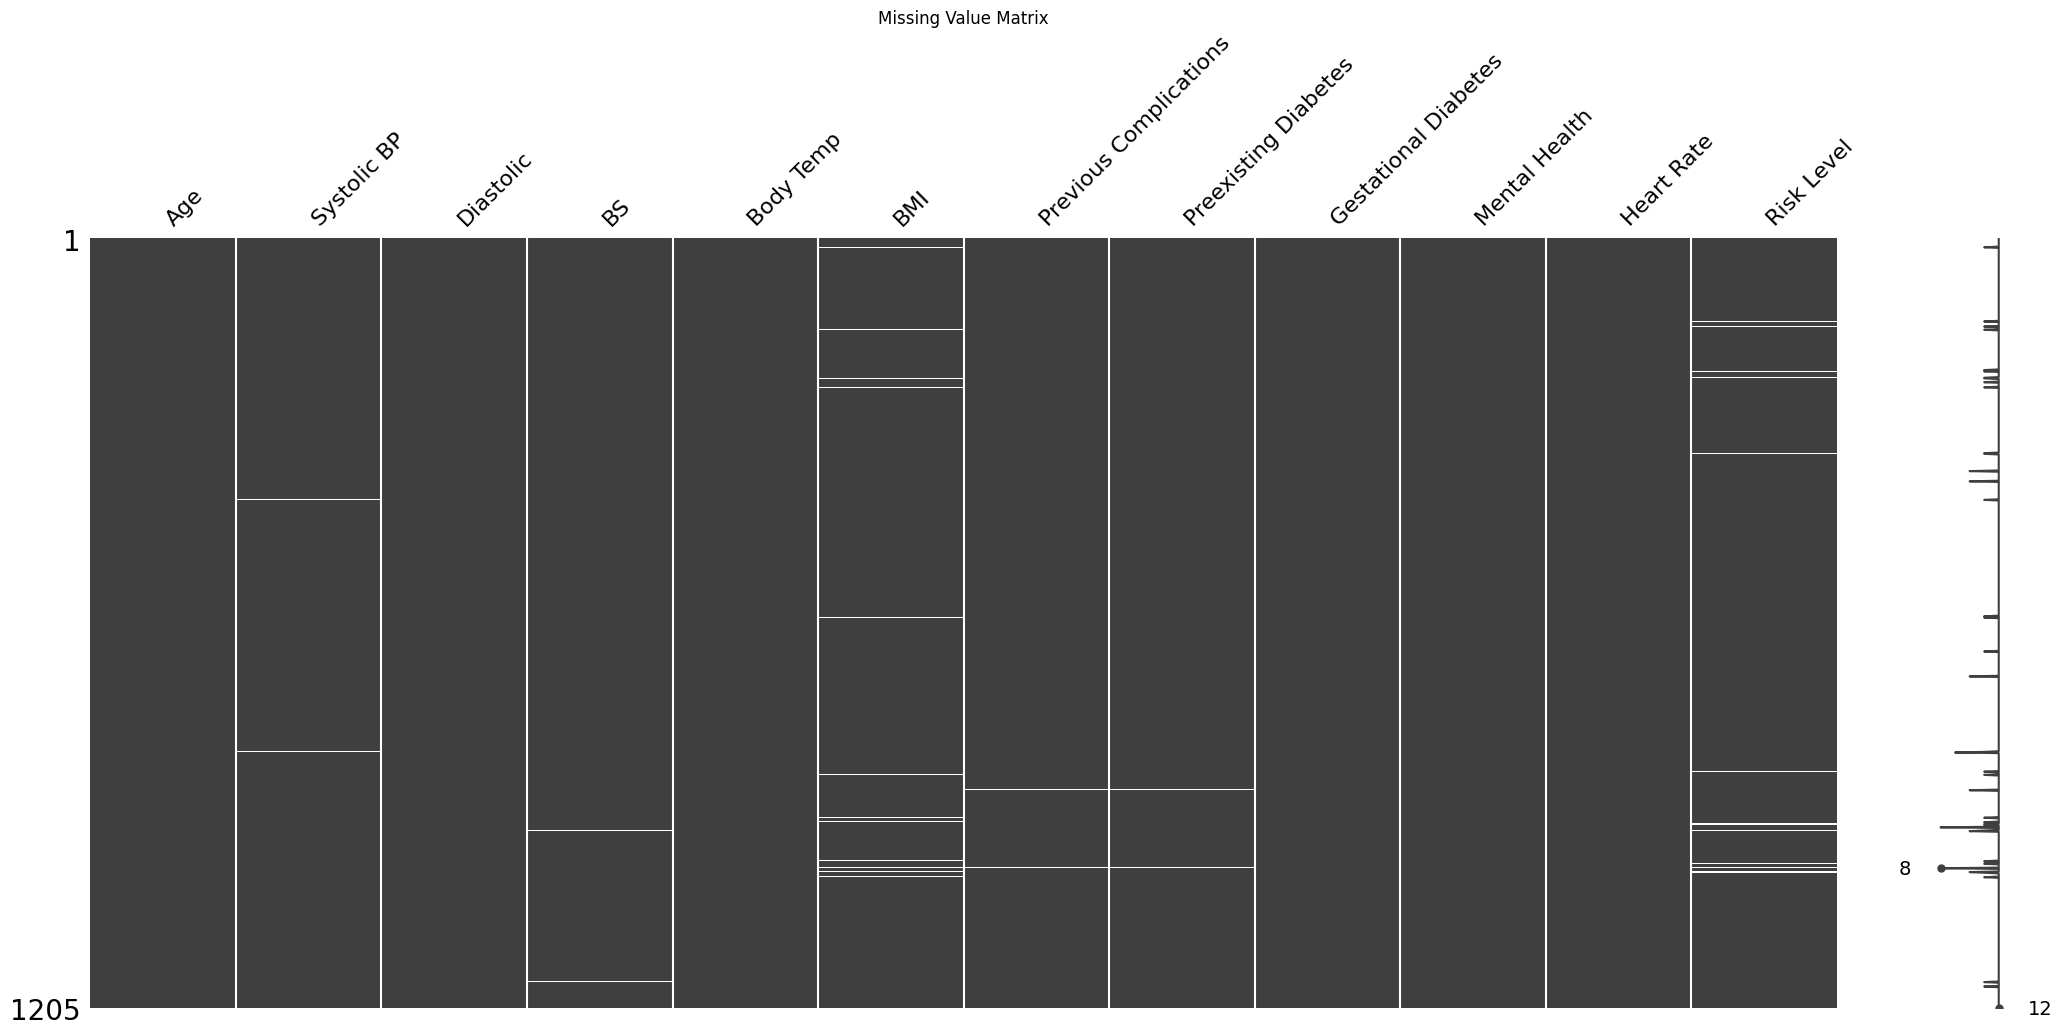

In [41]:
plt.figure()
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

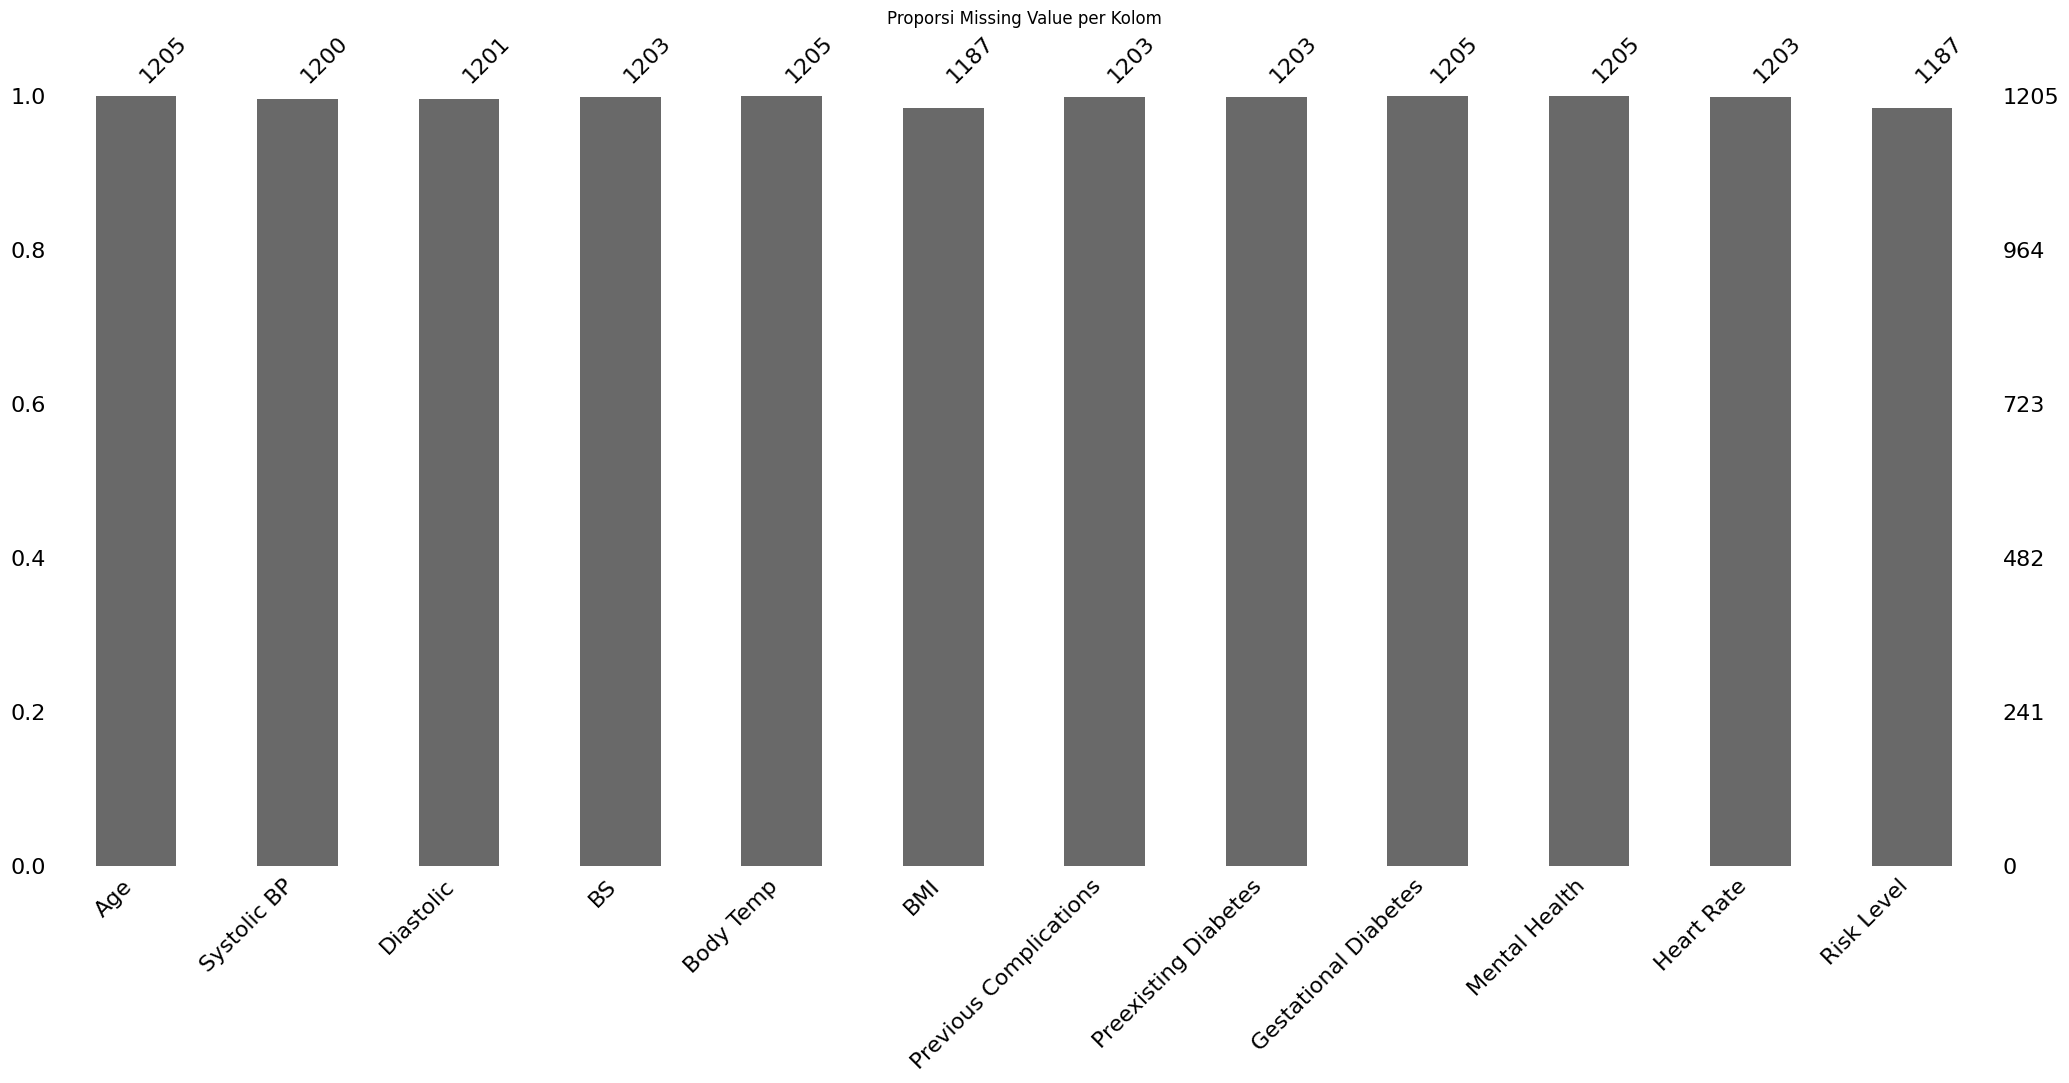

In [42]:
msno.bar(df)
plt.title("Proporsi Missing Value per Kolom")
plt.show()


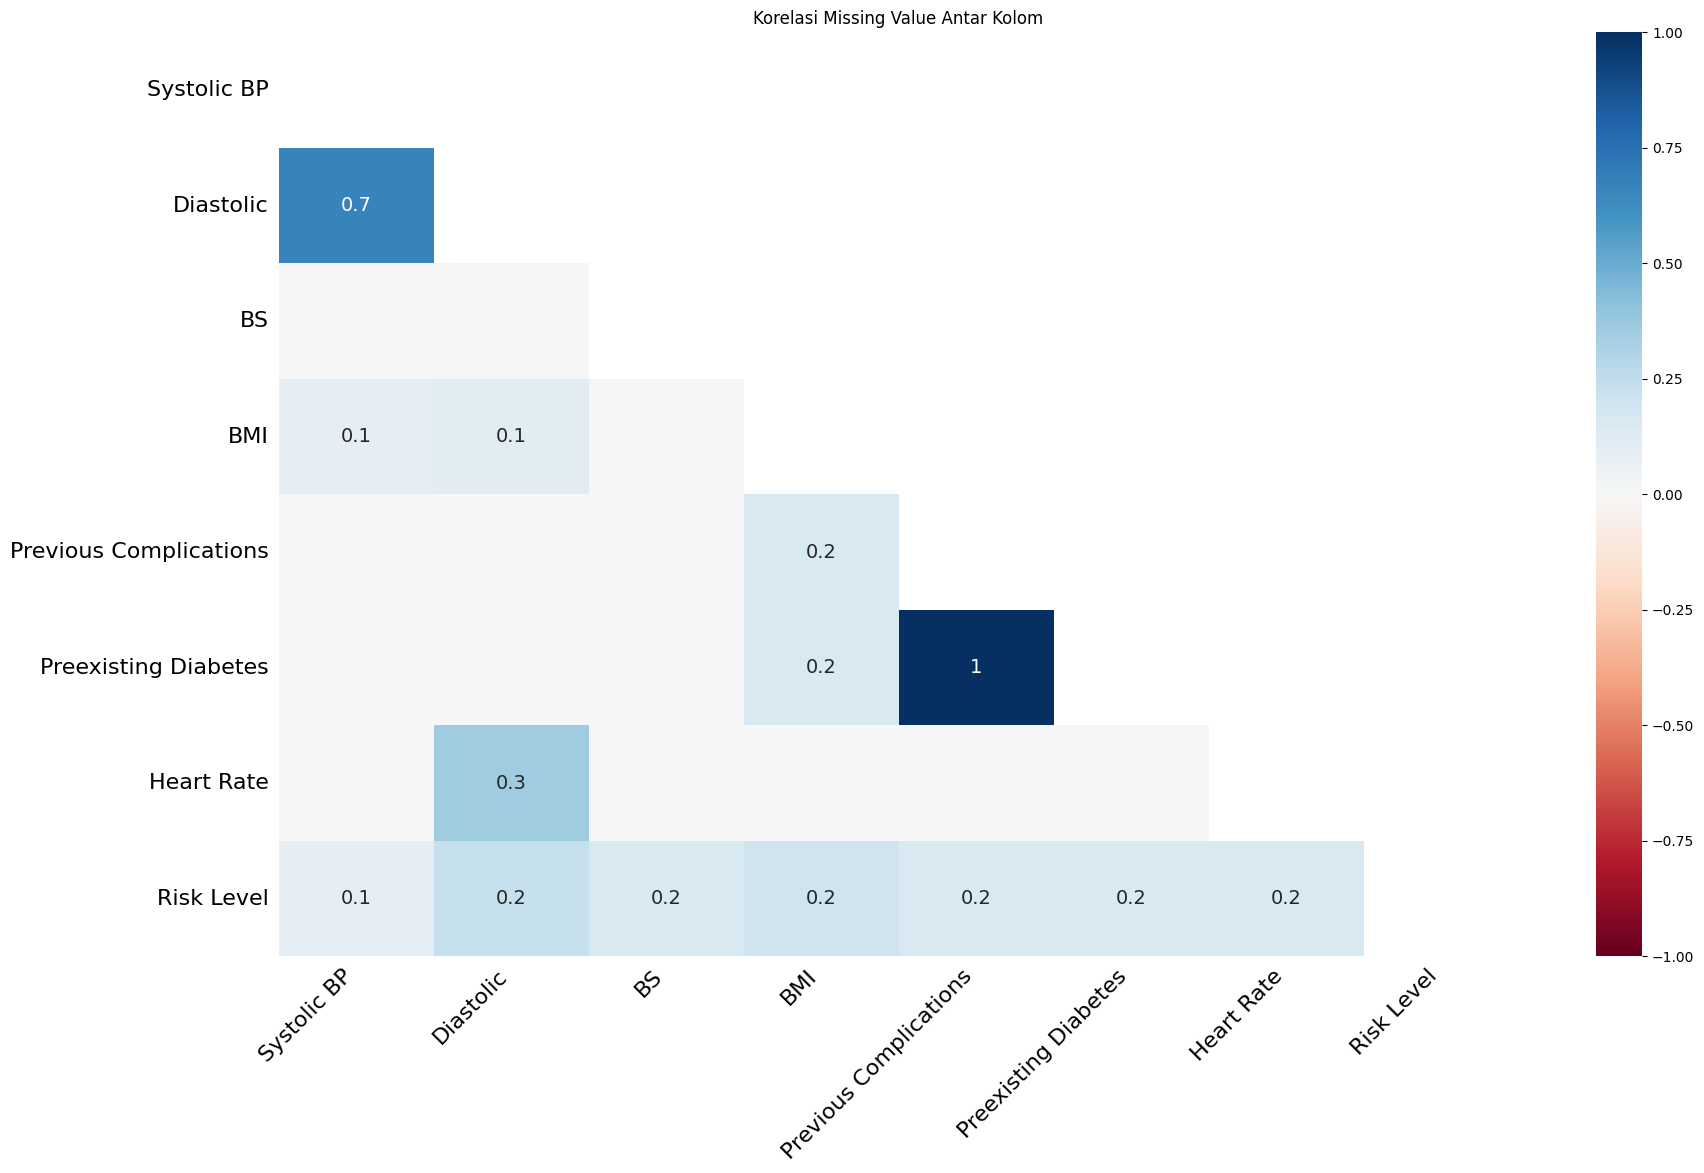

In [43]:
msno.heatmap(df)
plt.title("Korelasi Missing Value Antar Kolom")
plt.show()

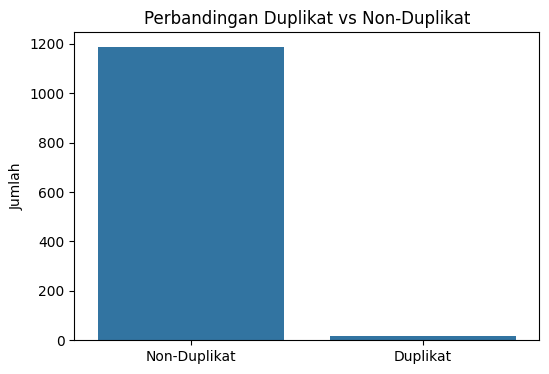

Non-Duplikat : 1187 (98.5%)
Duplikat     : 18 (1.5%)
Total        : 1205


In [44]:
total = len(df)
duplikat = df.duplicated().sum()
non_duplikat = total - duplikat

plt.figure(figsize=(6, 4))
sns.barplot(x=['Non-Duplikat', 'Duplikat'],
            y=[non_duplikat, duplikat])

plt.title('Perbandingan Duplikat vs Non-Duplikat')
plt.ylabel('Jumlah')
plt.show()

print(f"Non-Duplikat : {non_duplikat} ({non_duplikat/total*100:.1f}%)")
print(f"Duplikat     : {duplikat} ({duplikat/total*100:.1f}%)")
print(f"Total        : {total}")

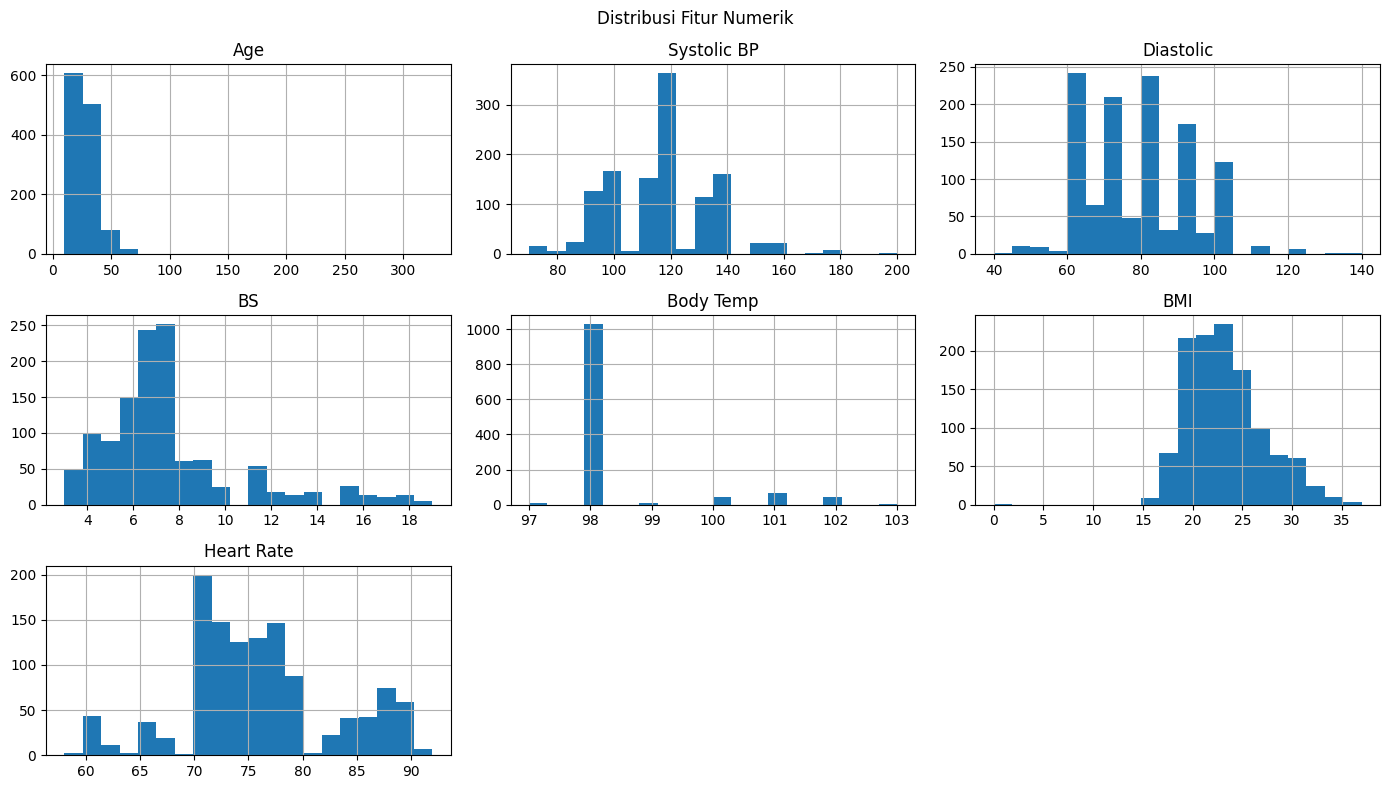

In [45]:
num_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

df[num_cols].hist(figsize=(14, 8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

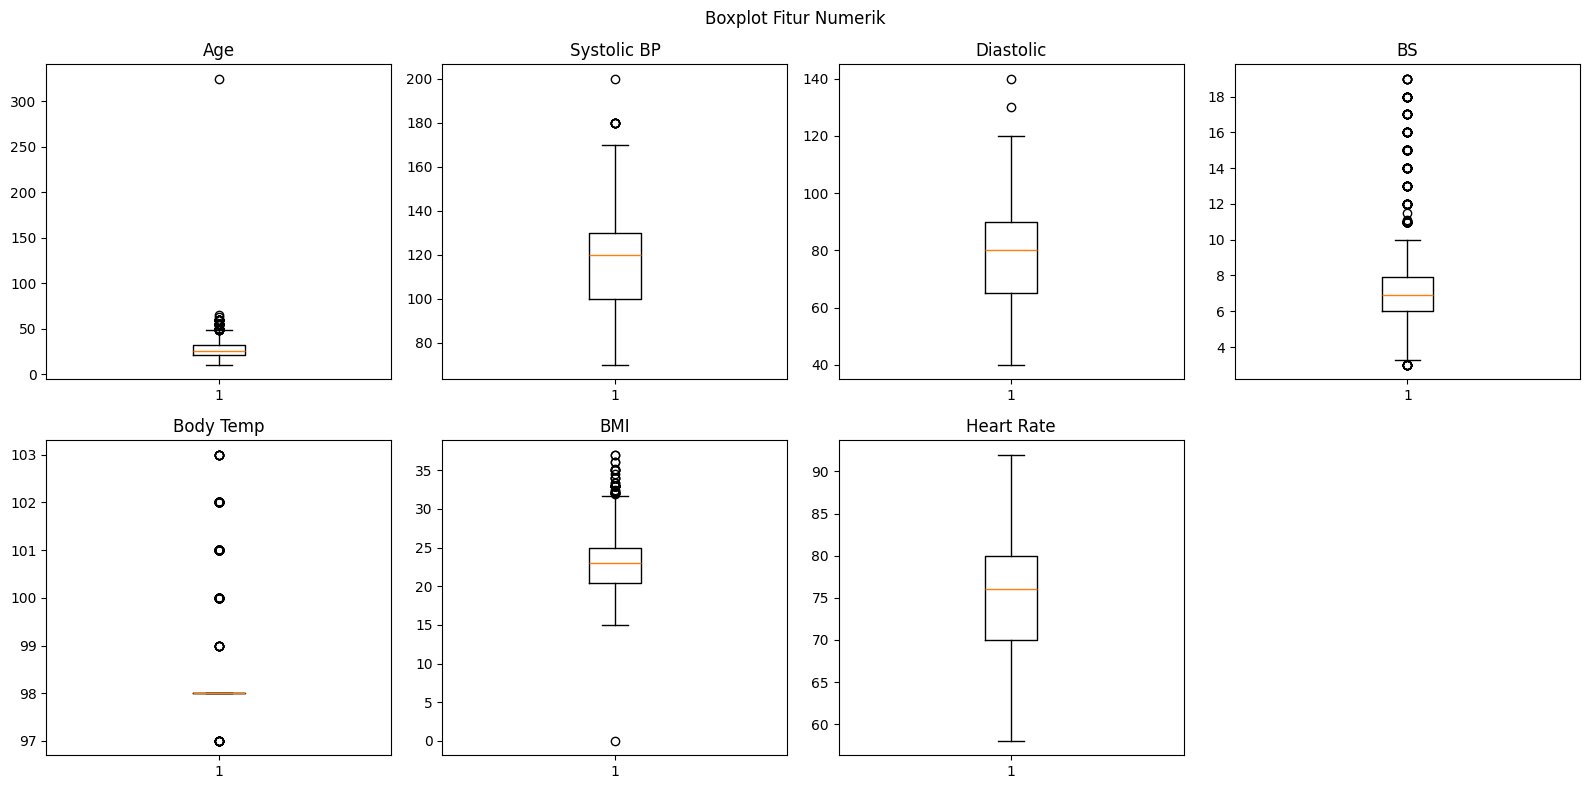

In [46]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

fig.delaxes(axes[7])

plt.suptitle('Boxplot Fitur Numerik')
plt.tight_layout()
plt.show()

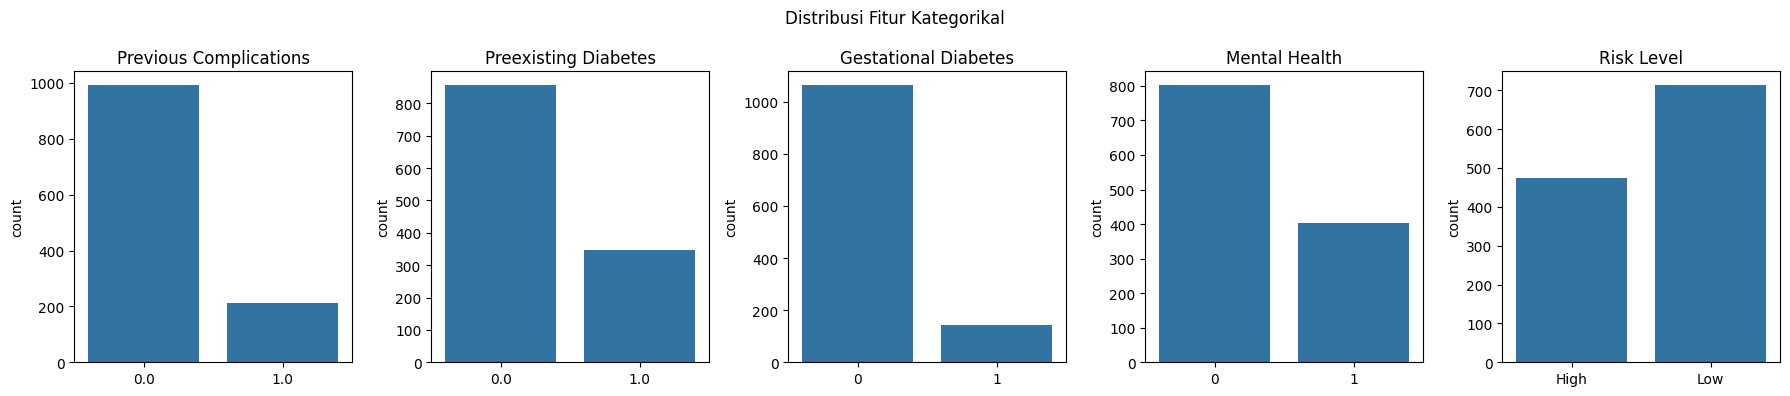

In [47]:
cat_cols = ['Previous Complications', 'Preexisting Diabetes',
            'Gestational Diabetes', 'Mental Health', 'Risk Level']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Kategorikal')
plt.tight_layout()
plt.show()

#Data Cleaning

In [48]:
df = df.drop_duplicates()

In [49]:
df = df.dropna(subset=['Risk Level'])

In [50]:
df = df[df['Age'] != 325]

In [51]:
df = df[df['BMI'] != 0.0]

In [52]:
print(f"Shape setelah Data Cleaning : {df.shape}")
print(f"Missing values tersisa:\n{df.isnull().sum()}")
print(f"Duplikat tersisa: {df.duplicated().sum()}")

Shape setelah Data Cleaning : (1167, 12)
Missing values tersisa:
Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64
Duplikat tersisa: 0


#Data Visualization

###Univariate

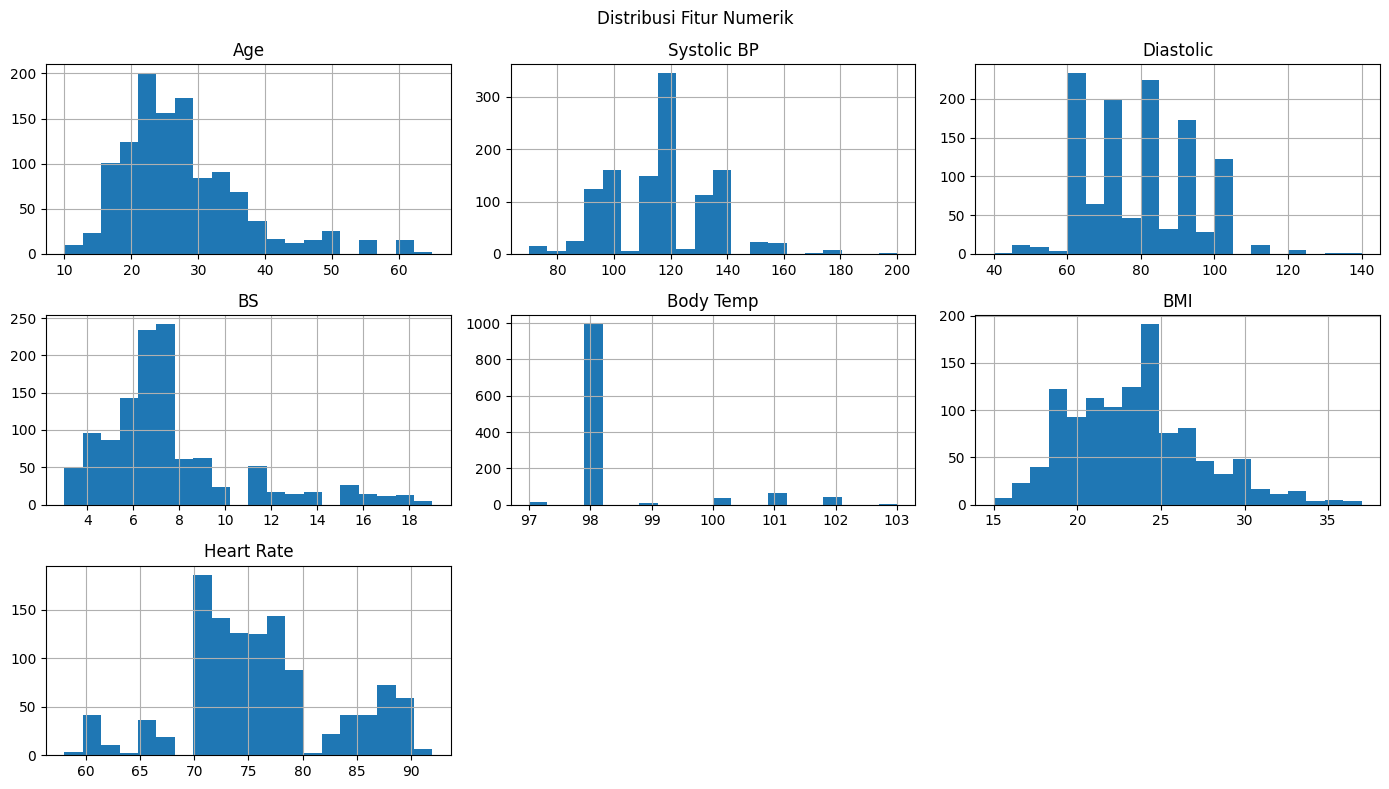

In [53]:
num_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

df[num_cols].hist(figsize=(14, 8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

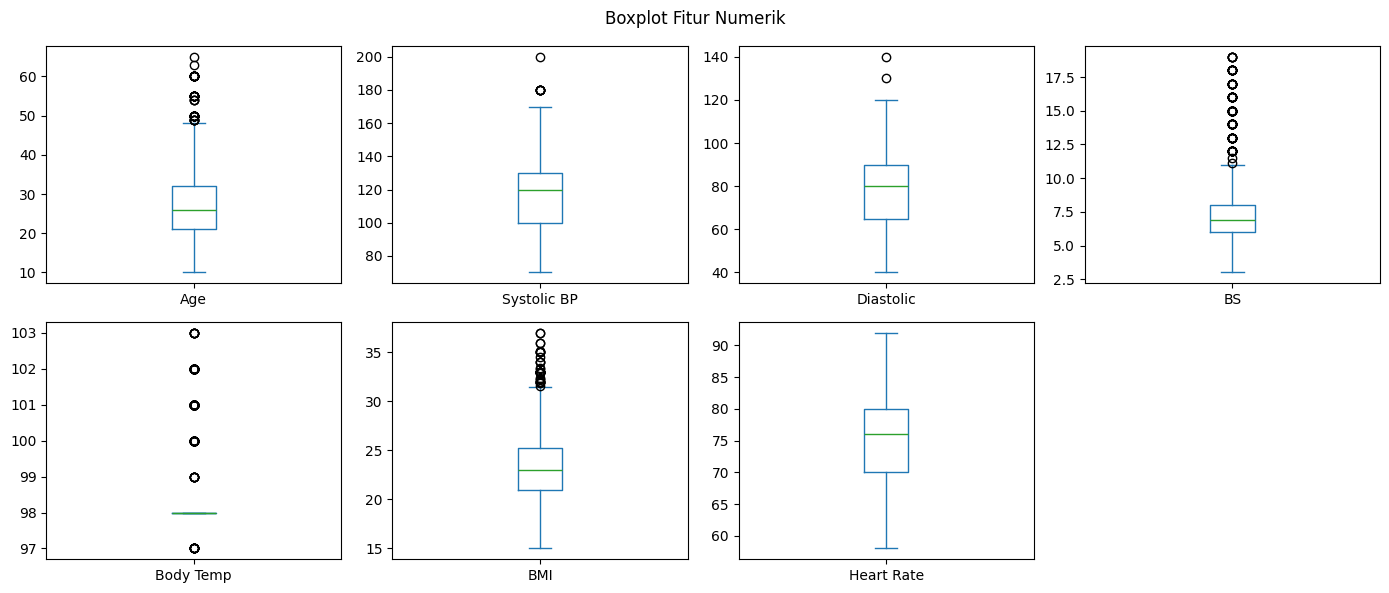

In [54]:
df[num_cols].plot(kind='box', figsize=(14, 6), subplots=True, layout=(2, 4))
plt.suptitle('Boxplot Fitur Numerik')
plt.tight_layout()
plt.show()

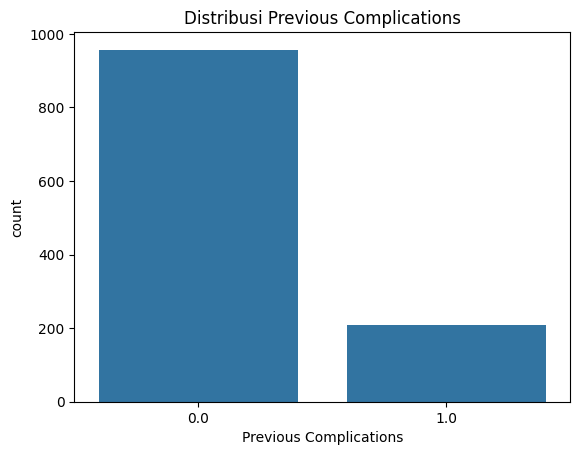

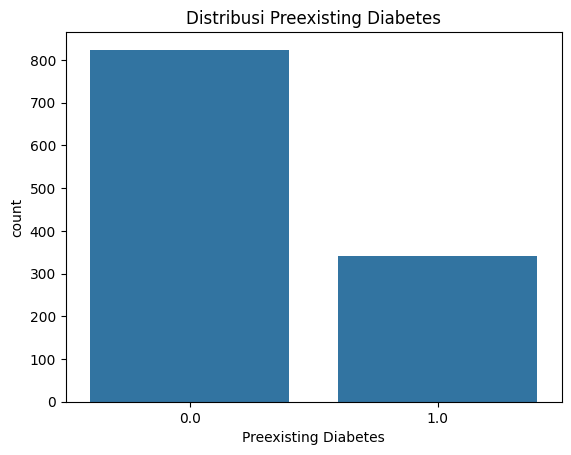

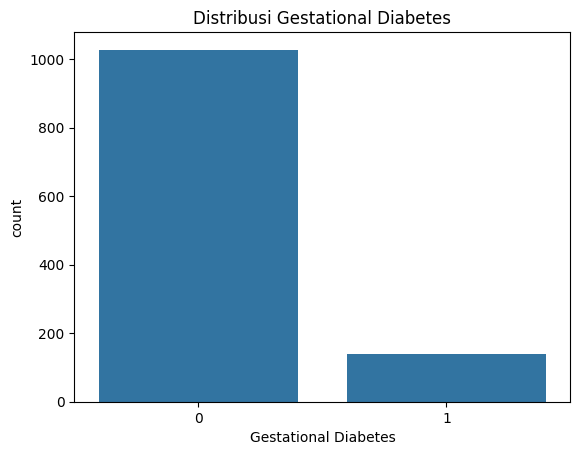

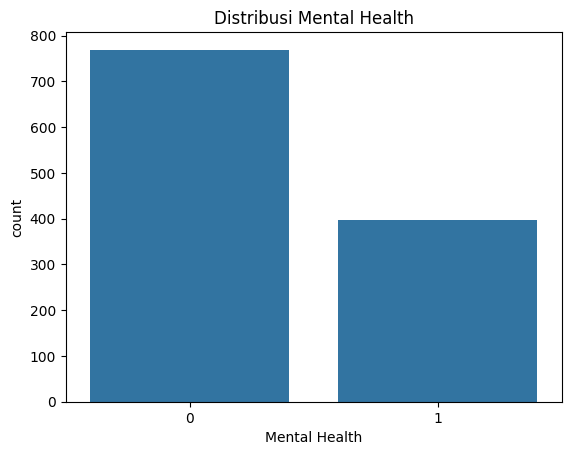

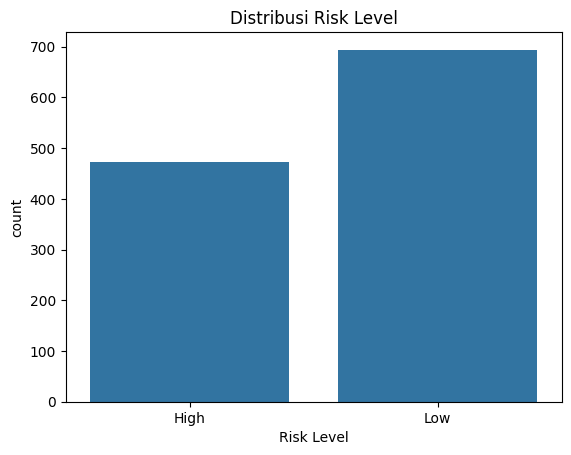

In [55]:
cat_cols = ['Previous Complications', 'Preexisting Diabetes',
            'Gestational Diabetes', 'Mental Health', 'Risk Level']

for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.title(f'Distribusi {col}')
    plt.show()

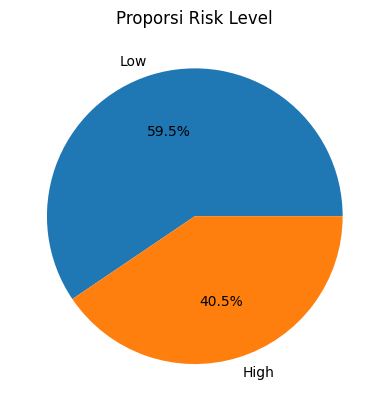

In [56]:
df['Risk Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporsi Risk Level')
plt.ylabel('')
plt.show()

###Bivariate

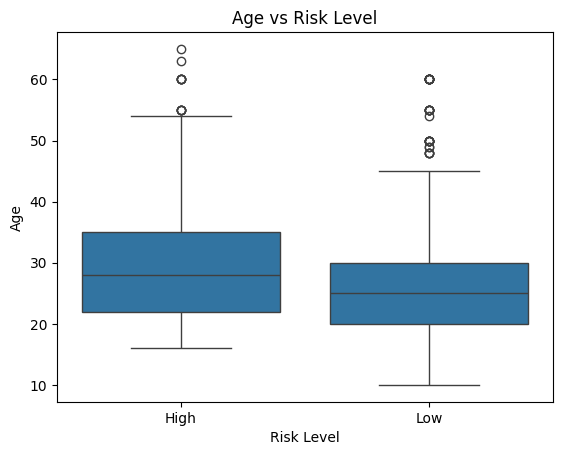

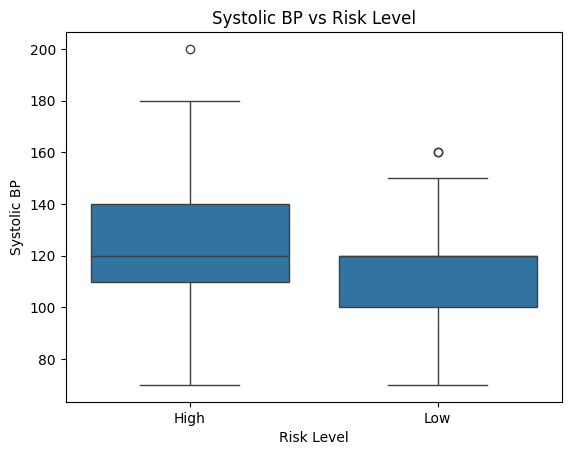

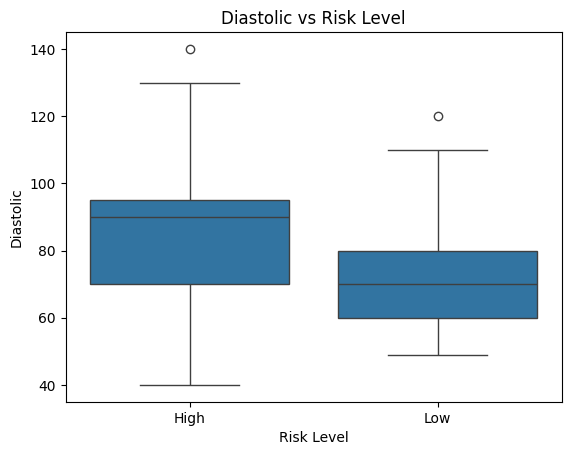

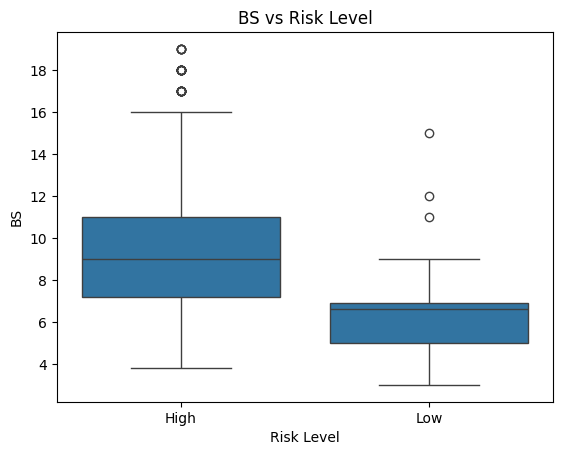

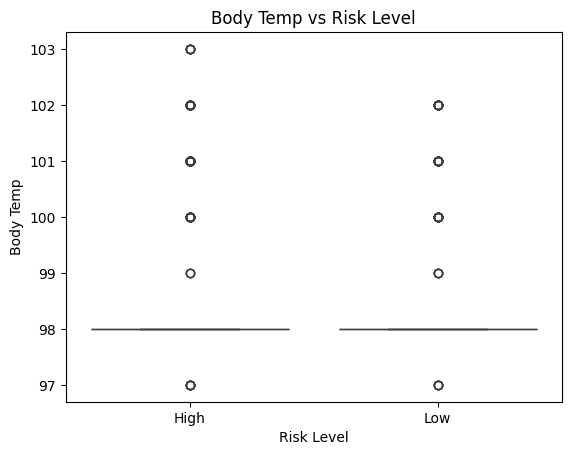

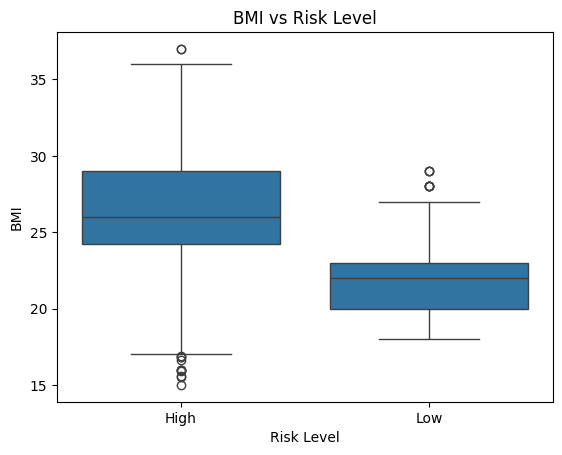

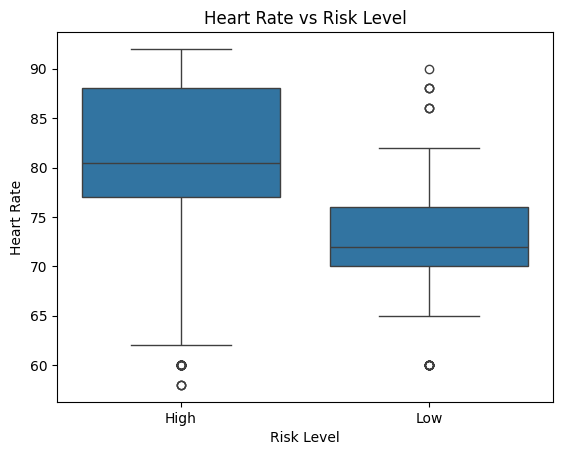

In [57]:
num_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

for col in num_cols:
    sns.boxplot(data=df, x='Risk Level', y=col)
    plt.title(f'{col} vs Risk Level')
    plt.show()

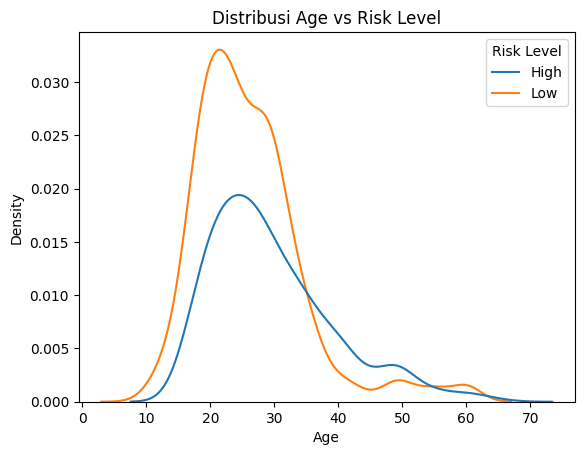

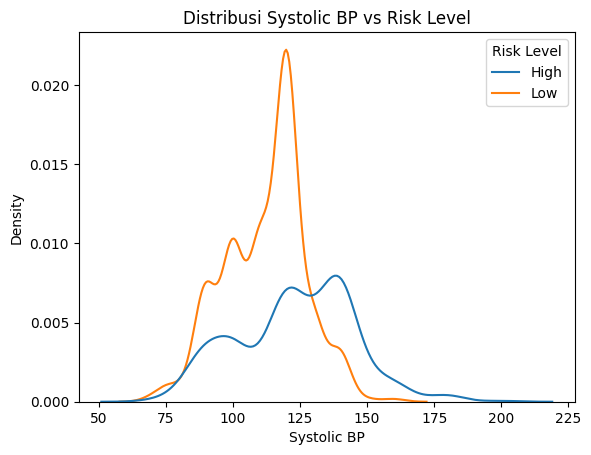

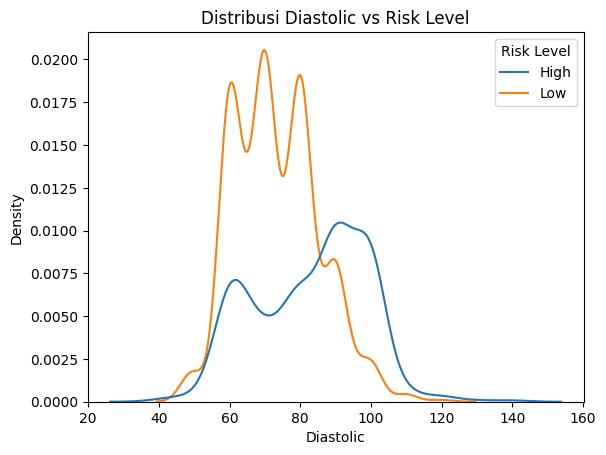

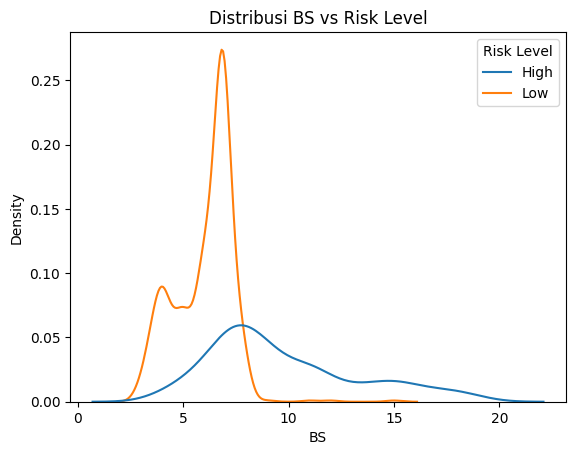

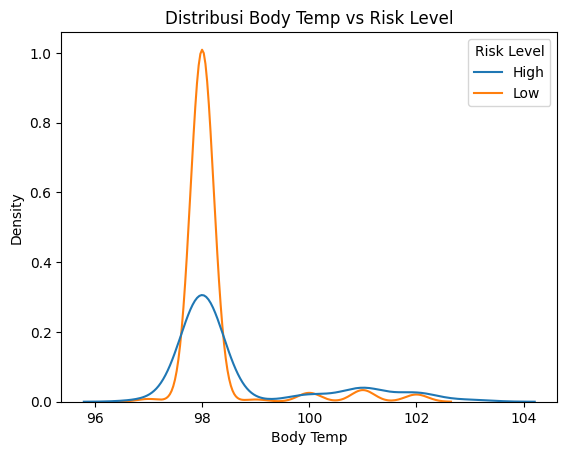

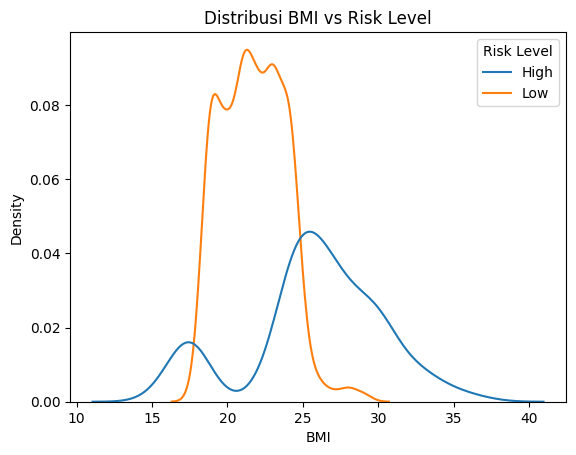

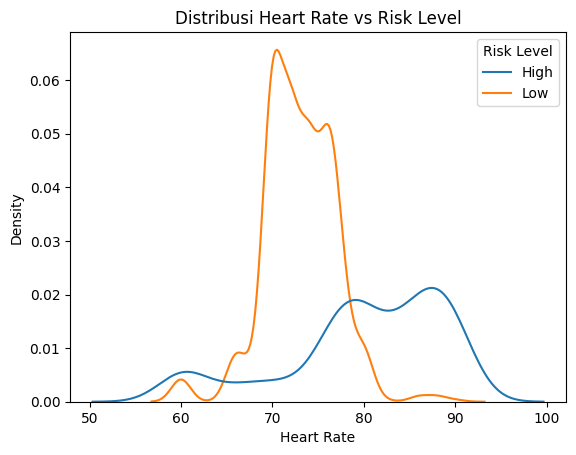

In [58]:
for col in num_cols:
    sns.kdeplot(data=df, x=col, hue='Risk Level')
    plt.title(f'Distribusi {col} vs Risk Level')
    plt.show()

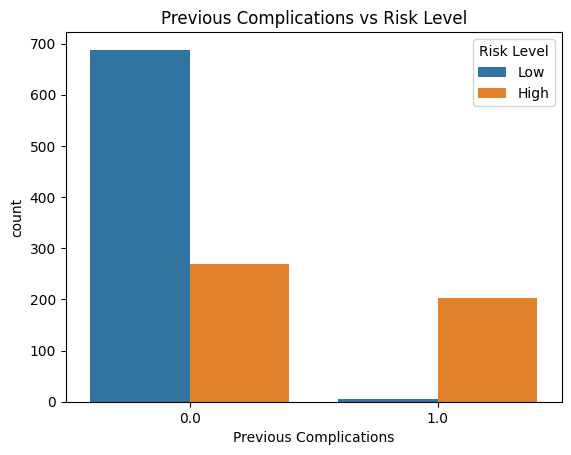

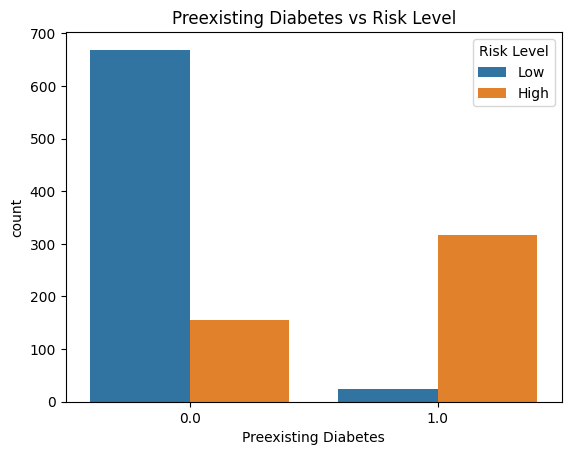

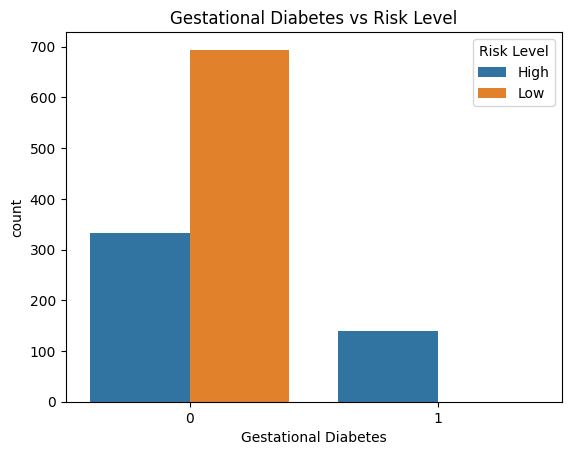

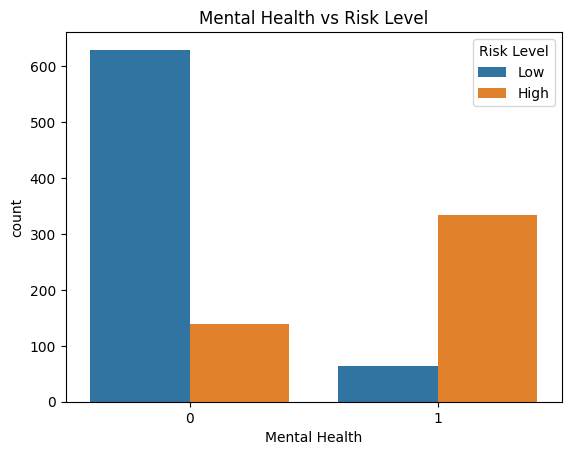

In [59]:
cat_cols = ['Previous Complications', 'Preexisting Diabetes',
            'Gestational Diabetes', 'Mental Health']

for col in cat_cols:
    sns.countplot(data=df, x=col, hue='Risk Level')
    plt.title(f'{col} vs Risk Level')
    plt.show()

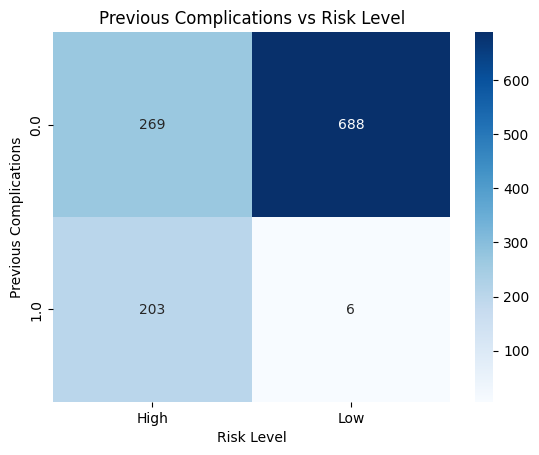

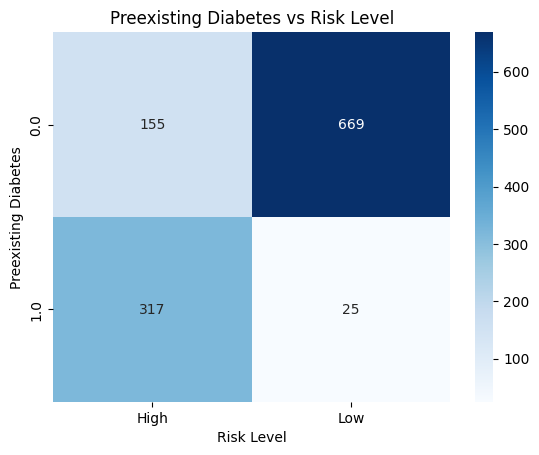

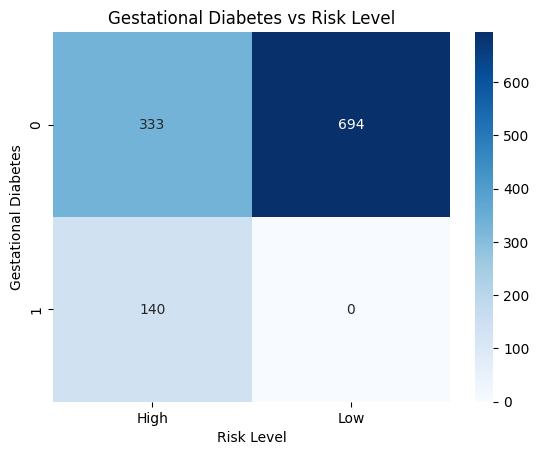

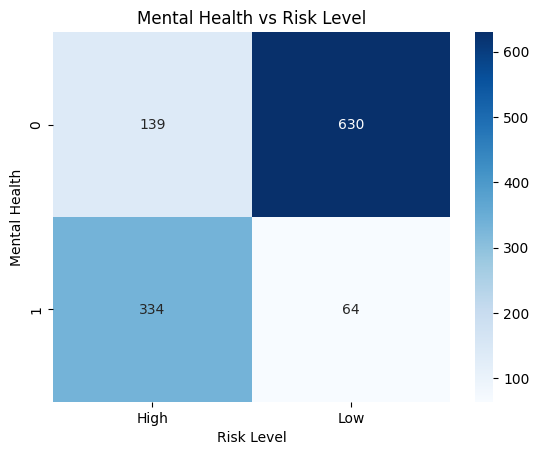

In [60]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Risk Level'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{col} vs Risk Level')
    plt.show()

###Multivariate

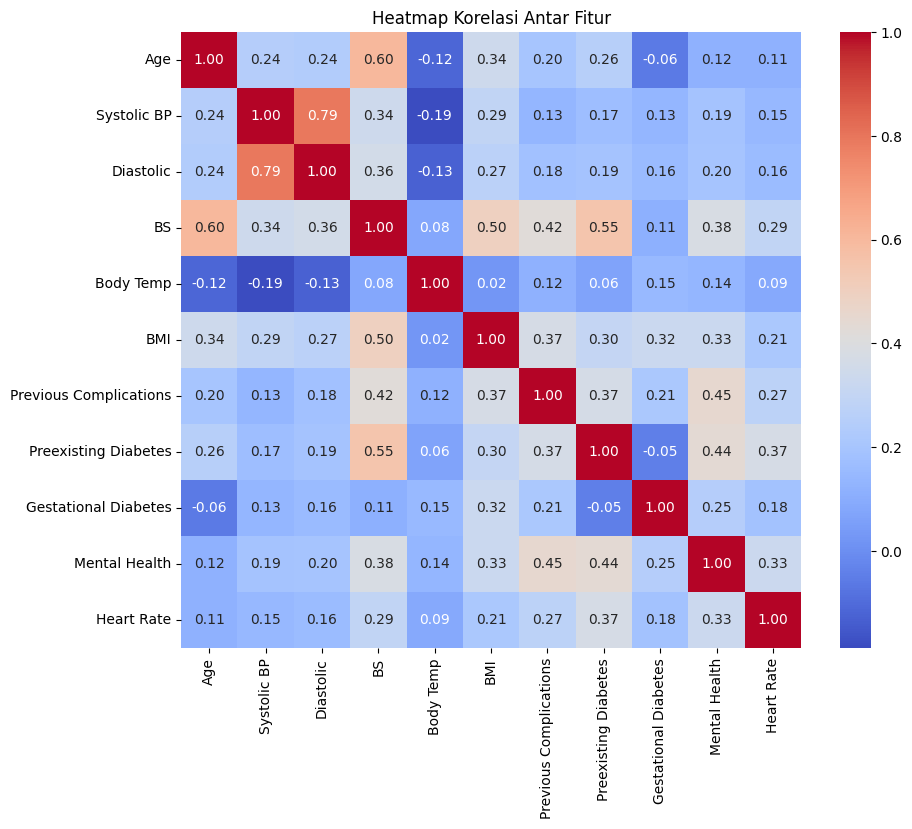

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

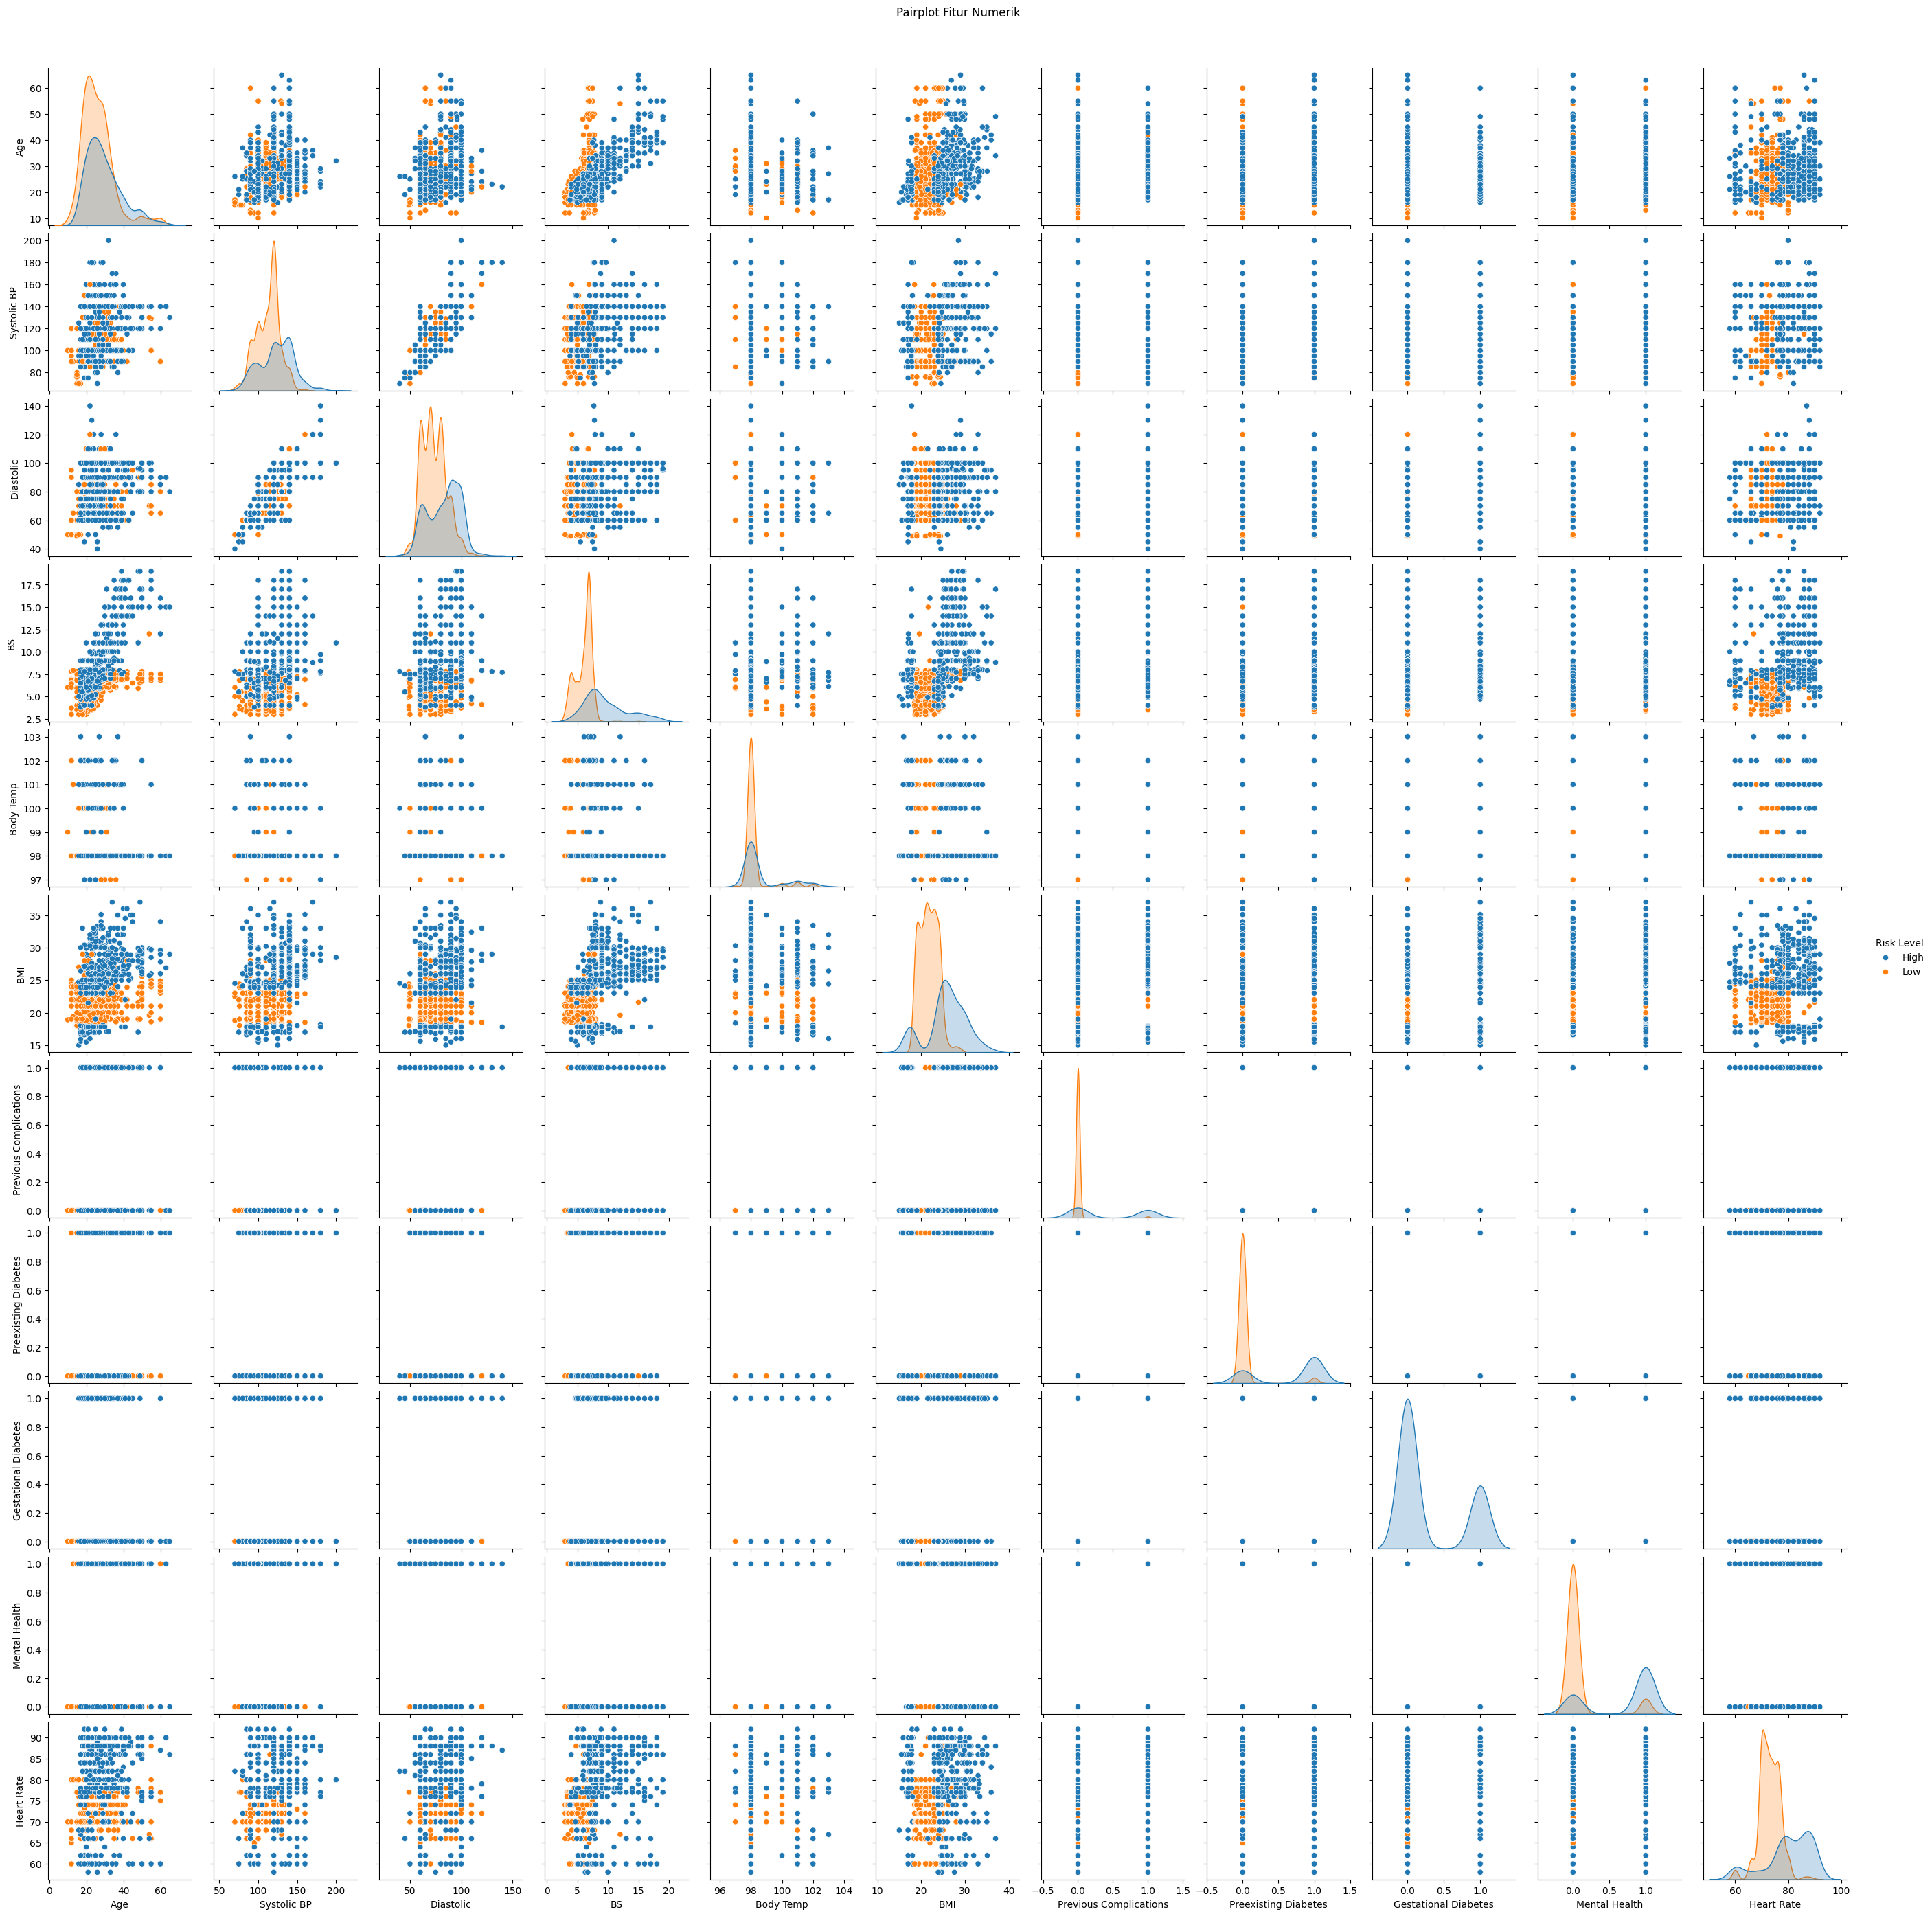

In [31]:
sns.pairplot(df, hue='Risk Level', diag_kind='kde')
plt.suptitle('Pairplot Fitur Numerik', y=1.02)
plt.show()

#Kesimpulan

*   Distribusi BS dan Age condong ke kanan (positively skewed)
*   Body Temp hampir semua nilainya sama jadi variasinya sangat kecil
*   Dataset ini termasuk kedalam mild imbalance dengan High Risk 40,5% dan Low Risk 59,5%
*   Blood Sugar (BS) adalah fitur yang paling jelas membedakan pasien yang berisiko tinggi dan rendah. Di mana pasien High Risk rata-rata memiliki kadar gula darah yang jauh lebih tinggi dibanding pasien Low Risk.
*   Pasien High Risk juga cenderung memiliki BMI, tekanan darah sistolik, dan tekanan darah diastolik yang lebih tinggi dibanding pasien Low Risk.
*   Suhu tubuh hampir tidak berbeda antara pasien High Risk dan Low Risk, sehingga fitur ini kurang berguna untuk membedakan tingkat risiko.
*   Tidak ada satupun pasien Low Risk yang memiliki Gestational Diabetes, kondisi ini hanya ditemukan pada pasien High Risk.
*    Pasien yang memiliki Preexisting Diabetes, gangguan Mental Health, atau riwayat komplikasi sebelumnya (Previous Complications) jauh lebih banyak ditemukan di kelas High Risk dibanding Low Risk.
*    Preexisting Diabetes, Mental Health, dan Blood Sugar adalah fitur yang paling berkorelasi dengan Risk Level
*    Body Temp dan Age korelasinya paling lemah terhadap Risk Level
*    Systolic BP dan Diastolic berkorelasi sangat tinggi satu sama lain karena keduanya sama-sama mengukur tekanan darah.
*    Blood Sugar dan Age juga cukup berkorelasi karena kadar gula darah cenderung naik seiring bertambahnya usia

